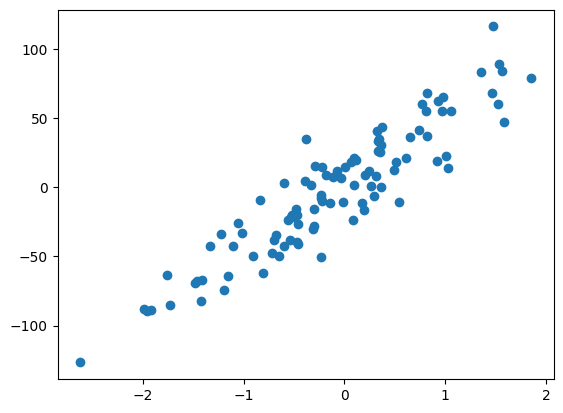

In [113]:
import numpy as np
from sklearn.datasets import make_regression
from matplotlib import pyplot as plt
X,y = make_regression(n_samples=100, n_features=1, n_targets=1,noise=20,random_state=42)
plt.scatter(X,y)

In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"slope is: {lr.coef_}")
print(f"interpt is: {lr.intercept_}")

y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
print(f"r2 score: {r2_score(y_test, y_pred)}")


slope is: [46.747264]
interpt is: 0.19844442845175525
r2 score: 0.8019015156159199


In [115]:
class GDRegressor:
    def __init__ (self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)

        print(self.b, self.m)   

    def predict(self,X):
        return self.m * X + self.b              

In [116]:
gd = GDRegressor(0.01, 100)
gd.fit(X_train, y_train)

0.19844442845154722 46.747263997070625


In [117]:
y_pred = gd.predict(X_test)
r2_score(y_test, y_pred)

0.8019015156159179